In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from lightgbm import LGBMClassifier

RANDOM_STATE = 777

In [2]:
df = pd.read_csv('..\\data\\processed\\diabetes_012_health_indicators_BRFSS2015_processed.csv')

X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Val:   {X_val.shape[0]} строк")
print(f"Test:  {X_test.shape[0]} строк")

Train: 177576 строк
Val:   38052 строк
Test:  38052 строк


In [4]:
def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred = model.predict(X_val)
    
    print(f"--- Оценка модели: {model_name} ---")
    print(classification_report(y_val, y_pred, target_names=['0: Здоров', '1: Преддиабет', '2: Диабет']))
    
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Здоров', 'Пред', 'Диабет'],
                yticklabels=['Здоров', 'Пред', 'Диабет'])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.show()

c:\Users\user\HSE\ML\hseml-group-project-armagedon\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--- Оценка модели: Logistic Regression ---
               precision    recall  f1-score   support

    0: Здоров       0.95      0.66      0.78     32056
1: Преддиабет       0.03      0.30      0.05       694
    2: Диабет       0.35      0.58      0.44      5302

     accuracy                           0.65     38052
    macro avg       0.44      0.51      0.43     38052
 weighted avg       0.85      0.65      0.72     38052



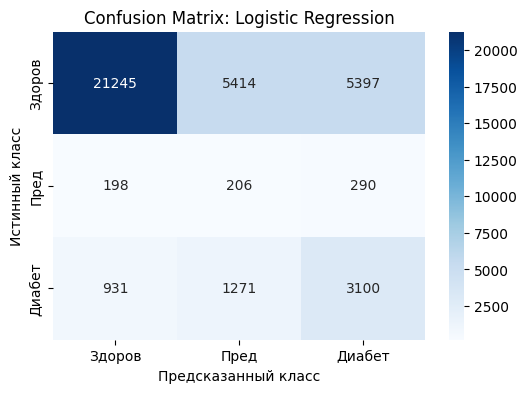

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)

evaluate_model(lr_model, X_val_scaled, y_val, "Logistic Regression")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 201
[LightGBM] [Info] Number of data points in the train set: 177576, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
--- Оценка модели: LightGBM Classifier ---
               precision    recall  f1-score   support

    0: Здоров       0.95      0.64      0.77     32056
1: Преддиабет       0.03      0.26      0.05       694
    2: Диабет       0.34      0.63      0.44      5302

     accuracy                           0.63     38052
    macro avg       0.44      0.51      0.42     38052
 weighted avg       0.85      0.63      0.71     38052



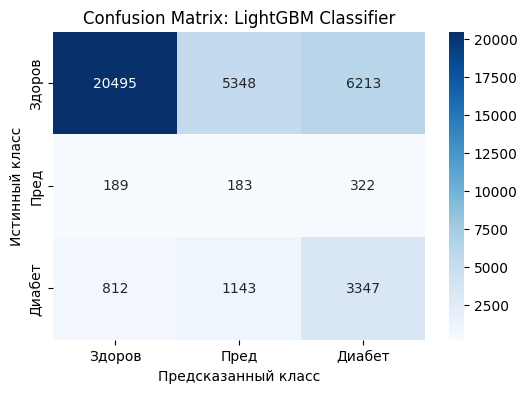

In [7]:
lgbm_model = LGBMClassifier(
    class_weight='balanced', 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    importance_type='gain'
)

lgbm_model.fit(X_train, y_train)

evaluate_model(lgbm_model, X_val, y_val, "LightGBM Classifier")

C:\Users\user\AppData\Local\Temp\ipykernel_26128\1718024386.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')


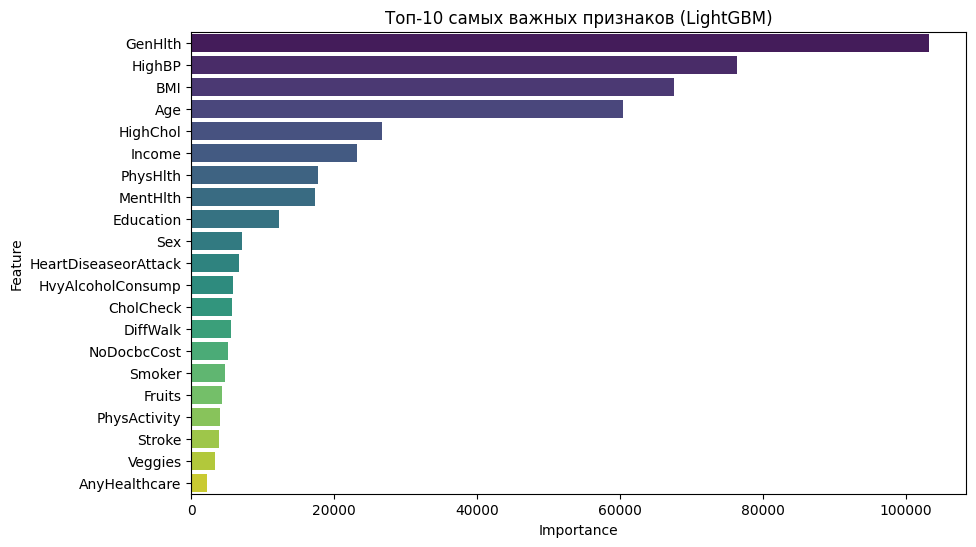

In [9]:
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp, palette='viridis')
plt.title('Топ-10 самых важных признаков (LightGBM)')
plt.show()